## Weather data

Most crop simulations require weather input data. Most commonly:
    - Solar irradiance (MJ/m2/day)
    - Precipation (mm/month)
    
And less important
    - Days with rain (1/month)
    
This demo comes with weather data files which can be found in the inputs folder.
    
**Note, these input files can for instance be opened/altered in Excel.**

In [1]:
# import pandas --- spreadsheet library
import pandas as pd

import numpy as np

# import matplotlib --- plotting library
import matplotlib.pyplot as plt 

In [2]:
%matplotlib inline

In [3]:
import os

fpath = '../../data/agrifood/KBD - 2006.xlsx'
dfo = pd.read_excel(fpath)

fpath = '../../data/agrifood/KBL - 2006 - weather.xlsx'
dfw = pd.read_excel(fpath)

In [4]:
dfw = dfw.resample('D').pad()

In [5]:
dfw = dfw.rolling('3D').mean()

dfw = dfw.fillna(method='pad')

In [6]:
import sys
sys.path.append('../PalmSim')
sys.path.append('..')
from palmsim import PalmField

# 1. Initialize the model
p = PalmField(year_of_planting=2003, month_of_planting= 6)

# 2. Couple the solar radiation data:
p.weather.radiation_series = dfw['Irradiation (MJ/m2/d)']

s = dfw['Precipitation (mm/month)']
s = s/s.index.days_in_month

p.weather.rainfall_series = s

#p.weather.rainfall_series = s

In [7]:
tw0, tw1 = dfw.index[0], dfw.index[-1]
tw0, tw1

(Timestamp('2006-01-01 00:00:00', freq='D'),
 Timestamp('2017-12-01 00:00:00', freq='D'))

In [8]:
p.date

'2003-6-1'

In [9]:
import time
import tqdm

In [10]:
t0 = time.time()

p.dt = 10

nyears = 18

duration = nyears*365

df = p.run(duration=duration)
    
t1 = time.time()

print(t1 - t0)

7.6914753913879395


13879.0
2006-01-01 00:00:00


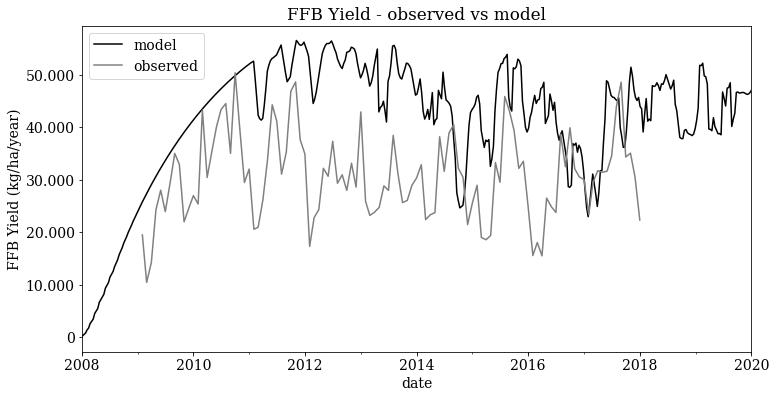

In [14]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 14

fig, ax = plt.subplots(figsize=(12,6))

df['generative_FFB_production (t/ha/yr)'].plot(ax=ax,color='black',ls='solid', label='model')

(12*1000*dfo['Y (t/ha/mo)']).plot(ax=ax, color='grey', label='observed')

ax.set_xlim('2008','2020')

t0, t1 = ax.get_xlim()

print(t0)
print(tw0)

y0, y1 = ax.get_ylim()

#ax.fill_between([t0,tw0],0, y1)
#ax.fill_between([tw1,t1],0, y1, color='grey', alpha=0.1, label='no weather data')

ax.set_yticklabels(["{:,}".format(int(y)).replace(',','.') for y in ax.get_yticks()])

ax.set_ylabel('FFB Yield (kg/ha/year)')

ax.set_title('FFB Yield - observed vs model')

ax.legend()

#plt.savefig('out.png', dpi=300)

In [15]:
xs = df['generative_FFB_production (t/ha/yr)'].astype(float).resample('1M').mean()
ys = (12*1000*dfo['Y (t/ha/mo)']).resample('1M').mean()

index = ys.index

ys = ys[index]
xs = xs[index]

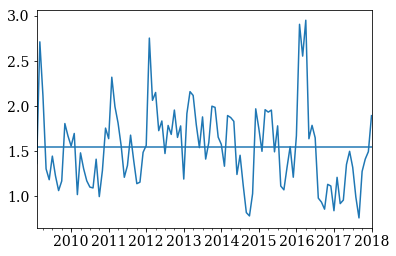

In [16]:
ax = (xs/ys).plot()
ax.axhline((xs/ys).mean())

In [17]:
xs = xs.values
ys = ys.values

In [18]:
from scipy.optimize import curve_fit

In [19]:
f = lambda x, a, b: a*x + b

coeffs, info = curve_fit(f, xs, ys)

In [20]:
coeffs

array([3.31972810e-01, 1.58436329e+04])

In [21]:
# SST = Sum(i=1..n) (y_i - y_bar)^2
# SSReg = Sum(i=1..n) (y_ihat - y_bar)^2
# Rsquared = SSReg/SST
# Where I use 'y_bar' for the mean of the y's, and 'y_ihat' to be the fit value for each point.

In [22]:
yfs = f(xs,*coeffs)

In [23]:
y_bar = ys.mean()

SST = ((ys - y_bar)**2).sum()
SSReg = ((yfs - y_bar)**2).sum()

Rsquared = SSReg/SST

Rsquared

0.10212636560407118

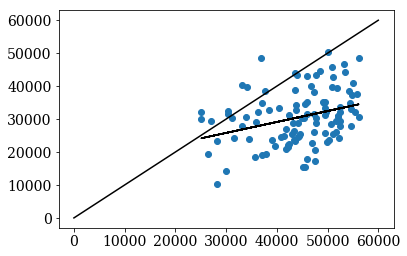

In [24]:
fig,ax = plt.subplots()

ax.scatter(xs,ys)

ax.plot(xs,yfs, c='black')

ax.plot([0,60000],[0,60000], color='black')

In [25]:
# ax = df['fronds_assim_produced2 (?)'].plot()
# df['fronds_assim_produced (kg_CH2O/ha/day)'].plot(ax=ax)
# #ax.set_xlim('2006','2020')
# ax.legend()

In [26]:
# ax = df['fronds_LUE2 (?)'].plot()
# ax.axhline(3.8)

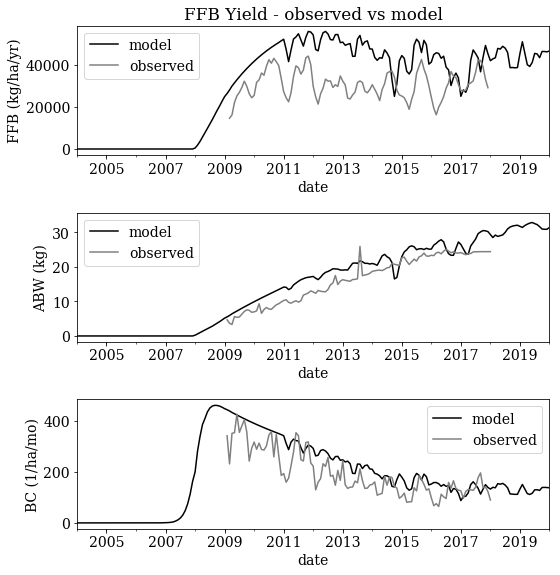

In [27]:
fig, axes = plt.subplots(3,1, figsize=(8,8))

ax = axes[0]

cm = 'black'
co = 'gray'

def smoothen(s):
    
    sm = s.astype('float').resample('M').mean()
    
    #sr = sm.rolling(3,center=True).mean()
    
    return sm

smoothen(df['generative_FFB_production (t/ha/yr)']).plot(ax=ax, label='model', c=cm)
(12*1000*dfo['Y (t/ha/mo)']).rolling(3,center=True).mean().plot(ax=ax, label='observed', c=co)
ax.set_ylabel('FFB (kg/ha/yr)')
ax.legend()

ax = axes[1]
smoothen(2*df['generative_bunch_weight (kg_DM)']).plot(ax=ax, label='model', c=cm)
dfo['ABW (kg)'].plot(ax=ax, label='observed', c=co)
ax.set_ylabel('ABW (kg)')
ax.legend()

ax = axes[2]
smoothen((365/12)*df['generative_bunch_count (1/ha/day)']).plot(ax=ax, label='model', c=cm)
ax = (dfo['BC (1/ha/mo)']).plot(ax=ax, label='observed', c=co)
ax.legend()
ax.set_ylabel('BC (1/ha/mo)')

for ax in axes:
    ax.set_xlim('2004','2020')

plt.tight_layout()
axes[0].set_title('FFB Yield - observed vs model')

plt.savefig('out-bfsig-{:}.png'.format(time.time()), dpi=300)

In [28]:
# fig, axes = plt.subplots(5,1, figsize=(12,12))

# ax = axes[0]
# df['weather_PAR (MJ/m2/day)'].plot(ax=ax, label='PAR (MJ/m2/day)')
# ax.set_ylabel('PAR (MJ/m2/day)')

# ax = axes[1]
# df['soil_moisture_content (1)'].plot(ax=ax, label='soil moisture')
# df['generative_Ic (1)'].plot(ax=ax, label='assimilate availability')
# ax.legend()
# ax.set_ylabel('Index (1)')

# ax = axes[2]
# df['generative_FFB_production (t/ha/yr)'].plot(ax=ax, label='model')
# (12*1000*dfo['Y (t/ha/mo)']).rolling(3,center=True).mean().plot(ax=ax, label='observed')
# ax.set_ylabel('FFB (kg/ha/yr)')
# ax.legend()

# ax = axes[3]
# (2*df['generative_bunch_weight (kg_DM)']).plot(ax=ax, label='model')
# dfo['ABW (kg)'].plot(ax=ax, label='observed')
# ax.set_ylabel('ABW (kg)')
# ax.legend()

# ax = axes[4]
# ((365/12)*df['generative_bunch_count (1/ha/day)']).plot(ax=ax, label='model')
# ax = (dfo['BC (1/ha/mo)']).plot(ax=ax, label='observed')
# ax.legend()
# ax.set_ylabel('BC (1/ha/mo)')

# for ax in axes:
#     ax.set_xlim('2008','2018')

# plt.tight_layout()

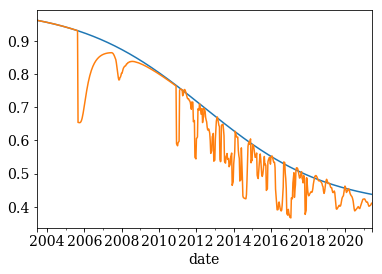

In [30]:
df['generative_female_fraction_baseline (?)'].plot()
df['generative_female_fraction (1)'].plot()

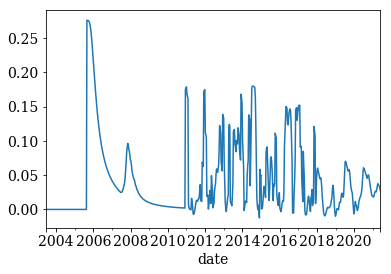

In [31]:
s = (df['generative_female_fraction_baseline (?)'] - df['generative_female_fraction (1)'])

s.plot()